In [ ]:
#pip install pandas

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving train.csv to train (3).csv


In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

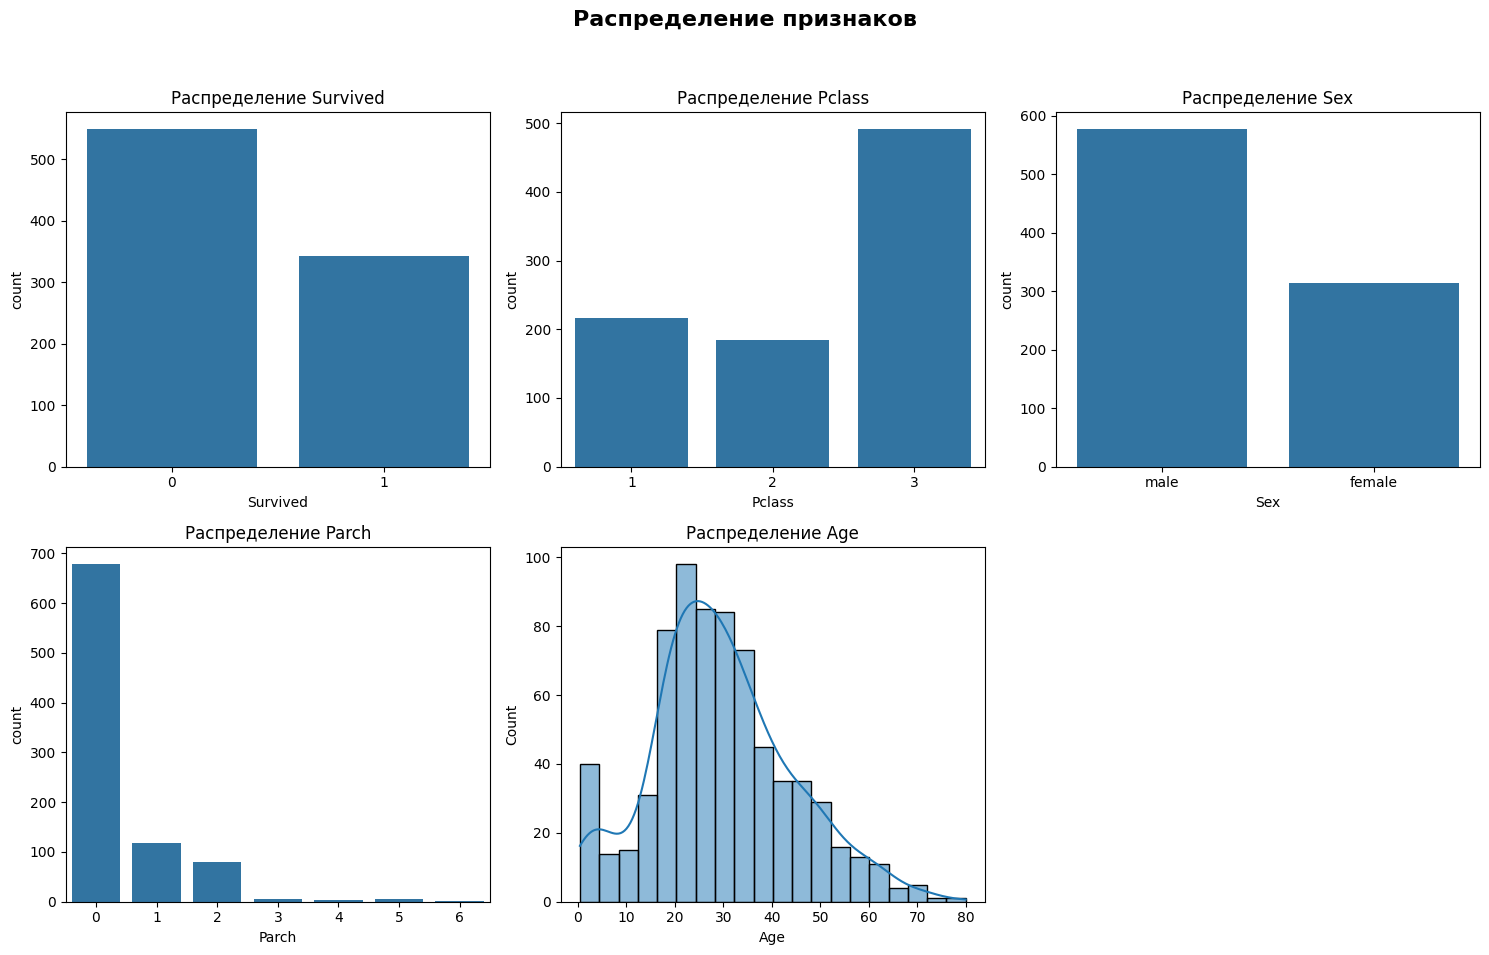

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Распределение признаков', fontweight='bold', fontsize=16)

sns.countplot(x='Survived', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Распределение Survived')
sns.countplot(x='Pclass', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Распределение Pclass')
sns.countplot(x='Sex', data=df, ax=axes[0, 2])
axes[0, 2].set_title('Распределение Sex')
sns.countplot(x='Parch', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Распределение Parch')
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Распределение Age')
fig.delaxes(axes[1, 2])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



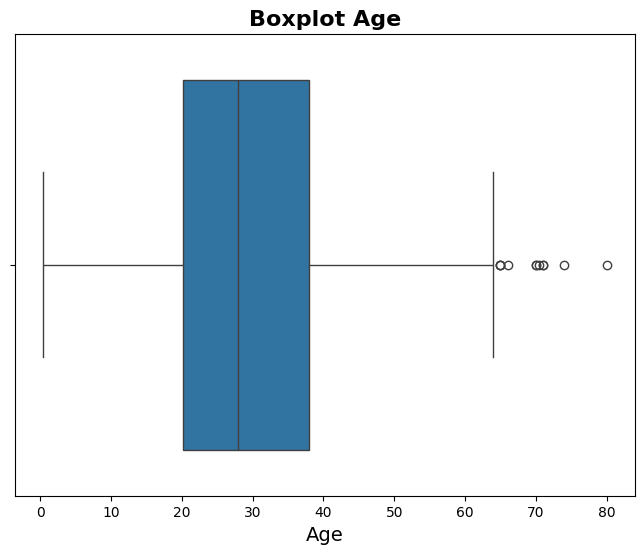

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Age'])
plt.title('Boxplot Age', fontweight='bold', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.show()

In [ ]:
print("Интерпретация Boxplot:")
print("- Медианный возраст пассажиров находится в районе 28-30 лет.")
print("- Межквартильный размах (IQR) показывает, что 50% пассажиров имеют возраст примерно от 20 до 38 лет.")
print("- Наблюдаются выбросы (outliers) в правой части графика — пассажиры старше 65-70 лет.")
print("- Распределение возраста имеет небольшую правостороннюю асимметрию.")

Интерпретация Boxplot:
- Медианный возраст пассажиров находится в районе 28-30 лет.
- Межквартильный размах (IQR) показывает, что 50% пассажиров имеют возраст примерно от 20 до 38 лет.
- Наблюдаются выбросы (outliers) в правой части графика — пассажиры старше 65-70 лет.
- Распределение возраста имеет небольшую правостороннюю асимметрию.


Text(0.5, 1.0, 'Доля классов обслуживания')

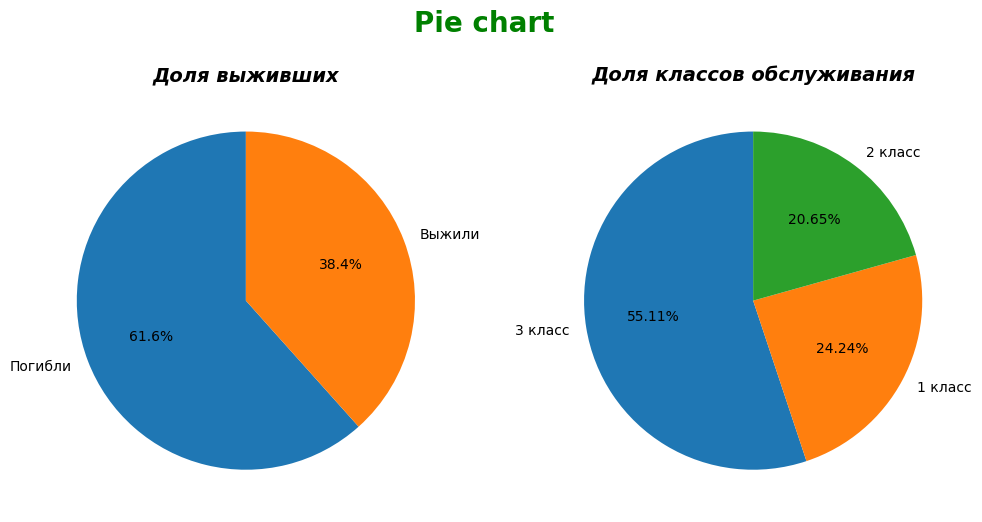

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Pie chart', fontweight='bold', fontsize=20, color='green',)
survived_counts = df['Survived'].value_counts()
axes[0].pie(survived_counts, labels=['Погибли', 'Выжили'], autopct='%1.1f%%', startangle=90,)
axes[0].set_title('Доля выживших', fontweight='bold', fontsize=14, fontstyle='italic')
pclass_counts = df['Pclass'].value_counts()
axes[1].pie(pclass_counts, labels=['3 класс', '1 класс', '2 класс'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Доля классов обслуживания', fontweight='bold', fontsize=14, fontstyle='italic')


Text(0.5, 1.0, 'Доля классов обслуживания')

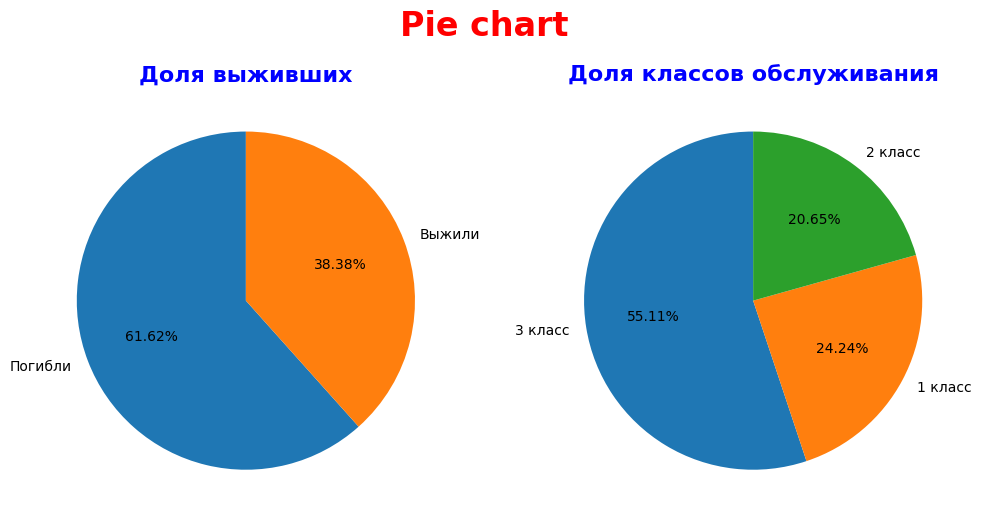

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Pie chart', fontweight='bold', fontsize=24, color='red')
survived_counts = df['Survived'].value_counts()
axes[0].pie(survived_counts, labels=['Погибли', 'Выжили'], autopct='%1.2f%%', startangle=90)
axes[0].set_title('Доля выживших', fontweight='bold', fontsize=16, color='blue')
pclass_counts = df['Pclass'].value_counts()
axes[1].pie(pclass_counts, labels=['3 класс', '1 класс', '2 класс'], autopct='%1.2f%%', startangle=90, )
axes[1].set_title('Доля классов обслуживания', fontweight='bold', fontsize=16, color='blue')


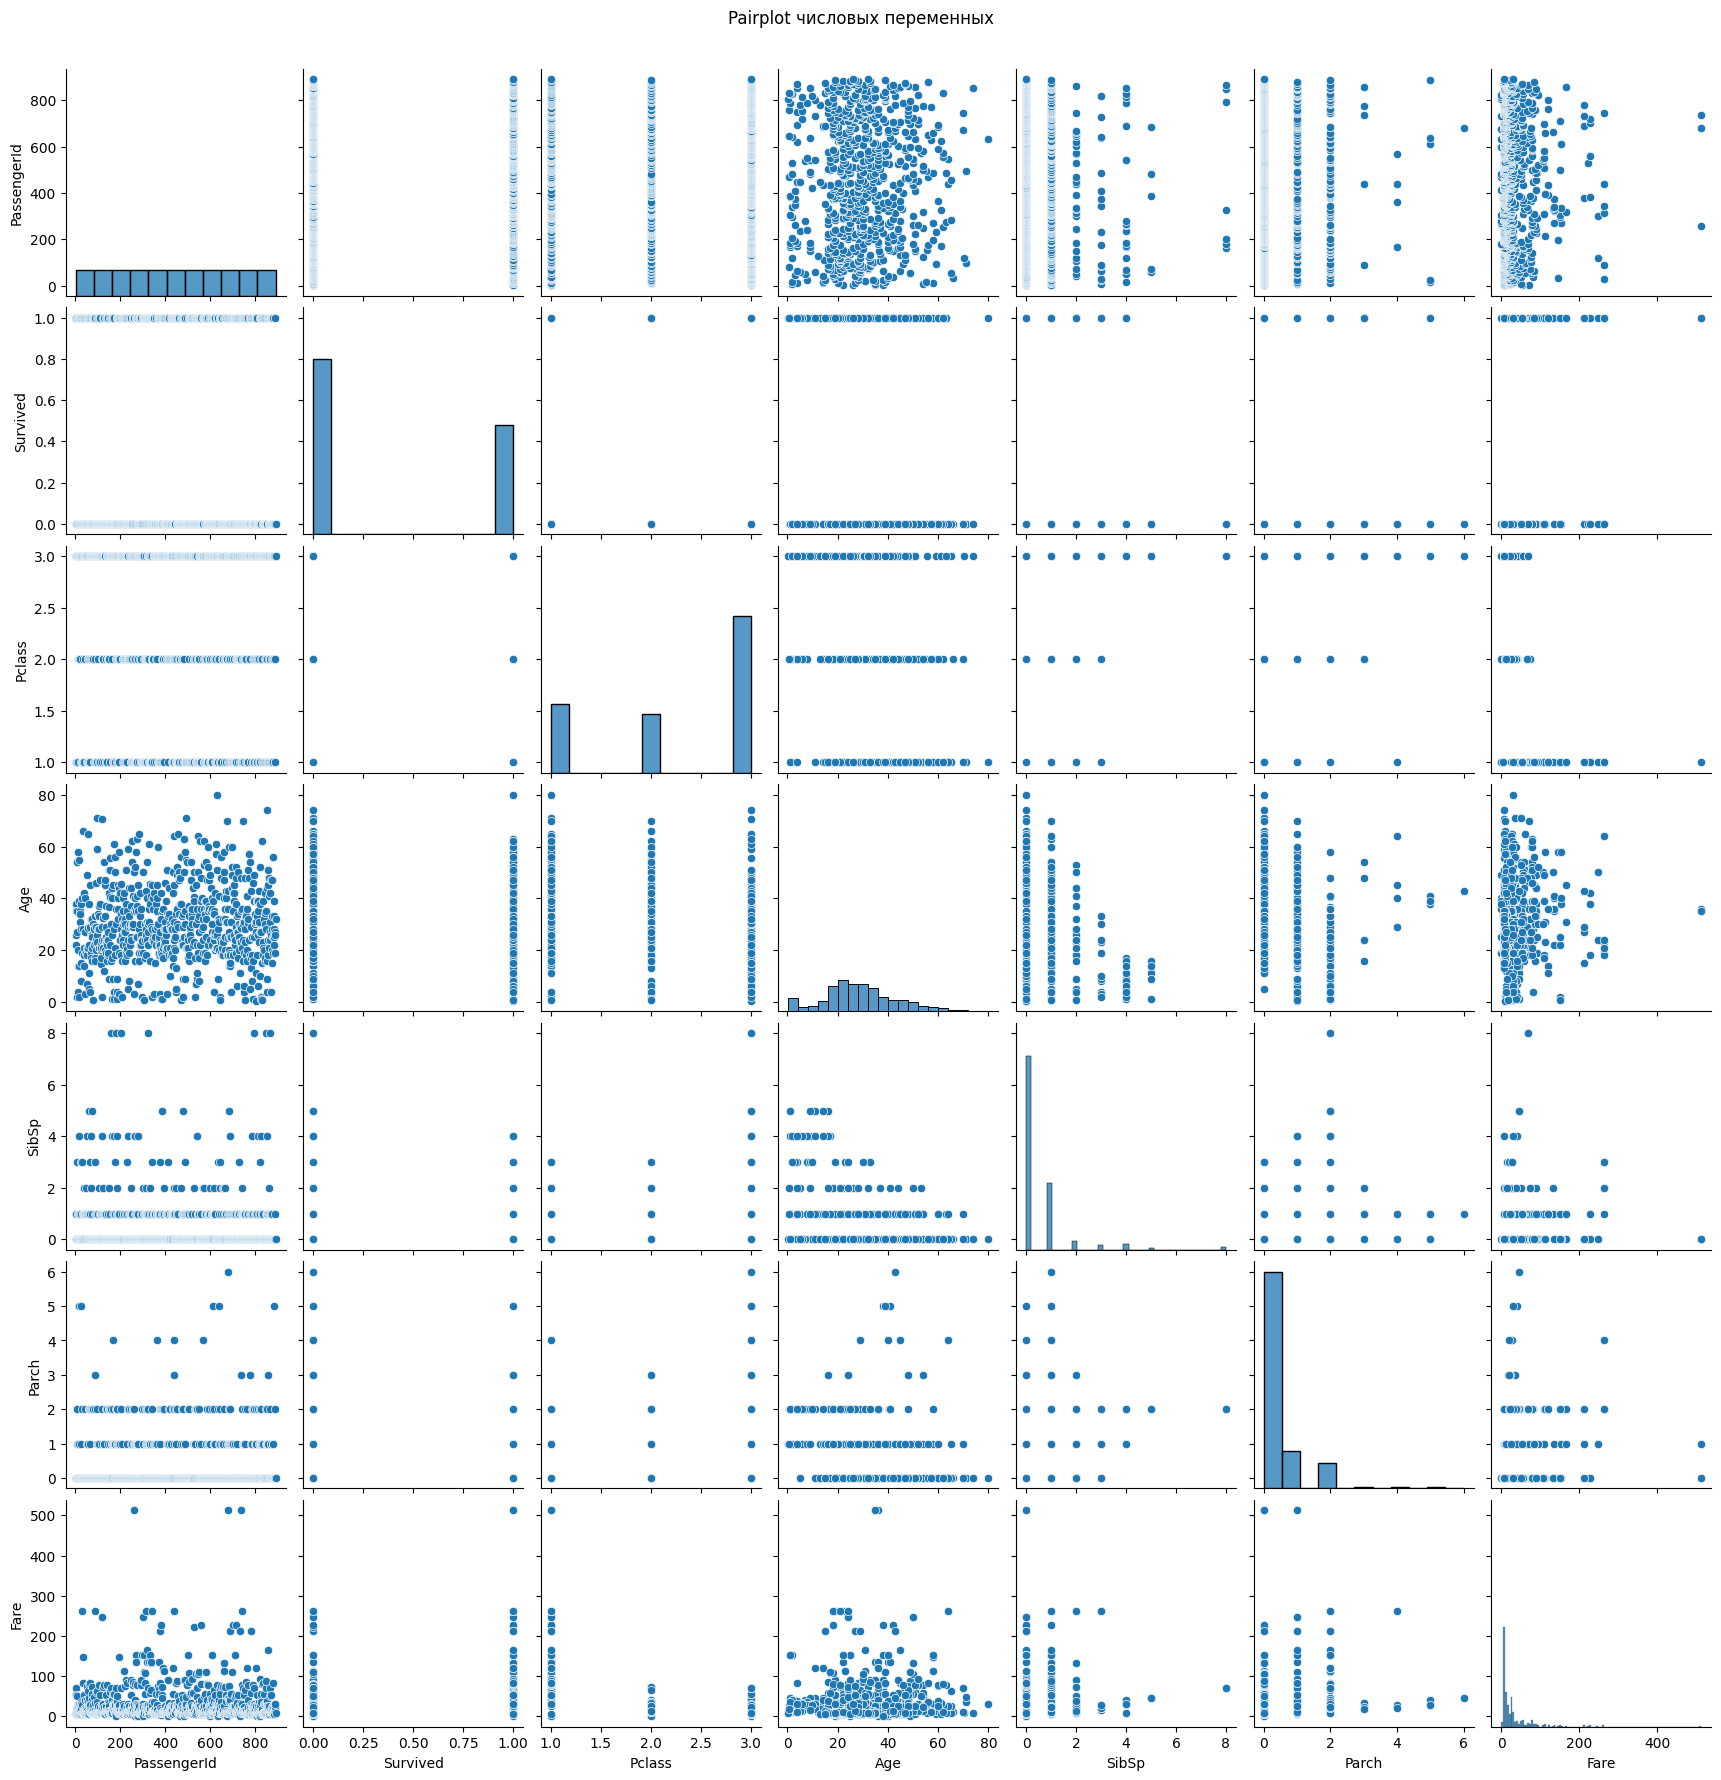

In [ ]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
sns.pairplot(numerical_df)
plt.suptitle('Pairplot числовых переменных', y=1.02)
plt.show()

In [152]:
sunburst_df = df.groupby(['Pclass', 'Sex']).size().reset_index(name='Count')
sunburst_df['Pclass'] = 'Класс ' + sunburst_df['Pclass'].astype(str)

fig = px.sunburst(
    sunburst_df,
    path = ['Pclass', 'Sex'],
    values = 'Count',
    title = 'Иерархия пассажиров по классу и полу',
    color = 'Pclass',
    color_discrete_map = {'(?)':'black', 'Класс 1':'green', 'Класс 2':'red', 'Класс 3':'blue'}
)
fig.update_traces(textinfo="label+percent root")
fig.show()

